In [1]:
#Librerías 
#!pip install wordcloud
#!pip install spacy
!python -m spacy download es_core_news_sm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import spacy

nlp = spacy.load("es_core_news_sm")

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ------- -------------------------------- 2.4/12.9 MB 11.8 MB/s eta 0:00:01
     -------------- ------------------------- 4.7/12.9 MB 11.8 MB/s eta 0:00:01
     --------------------- ------------------ 7.1/12.9 MB 11.8 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.9 MB 11.8 MB/s eta 0:00:01
     ----------------------------------- --- 11.8/12.9 MB 11.8 MB/s eta 0:00:01
     --------------------------------------- 12.9/12.9 MB 11.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [6]:
palabras_a_conservar = {
    'no', 'ni', 'nunca', 'jamás', 'jamas', 'tampoco', 'nada', 'nadie',
    'ningún', 'ninguna', 'ninguno', 'sin',
    'sí', 'si', 'también', 'tambien', 'siempre', 'claro',
    'pero', 'aunque', 'más', 'mas', 'menos', 'muy', 'poco', 'mucho'
}

def limpiar_stopwords(texto):
    if not isinstance(texto, str):
        return texto
    doc = nlp(texto)
    tokens = [
        token.text for token in doc
        if not token.is_stop or token.text.lower() in palabras_a_conservar
    ]
    return ' '.join(tokens)

In [7]:
#Datasets
ruta1 = "DATASET_DRL_LIMPIO1.csv"
df1 = pd.read_csv(ruta1)
ruta2 = "DATASET_DRL_LIMPIO2.csv"
df2 = pd.read_csv(ruta2)
# Consolidadar DF

# 1. Concatenar los DataFrames verticalmente
# ignore_index=True evita que los índices se repitan (0, 1, 2... de cada DF)
df_total = pd.concat([df1, df2], ignore_index=True)

# 2. Recomendación técnica: Eliminar duplicados globales
# Es posible que una noticia esté en ambos archivos. 
# Usamos 'Titulo_norm' para asegurar unicidad.
n_antes = len(df_total)
df_total = df_total.drop_duplicates(subset=['Titulo_norm'], keep='first')
n_despues = len(df_total)

# 3. Guardar el corpus final unificado
df_total.to_csv('DATASET_DRL_CONSOLIDADO.csv', index=False)

# Métricas de la unión
print(f"Registros tras la unión: {n_antes}")
print(f"Registros tras eliminación de duplicados cruzados: {n_despues}")
print(f"Duplicados eliminados en la fusión: {n_antes - n_despues}")
print("Archivo 'DATASET_DRL_CONSOLIDADO.csv' generado con éxito.")

Registros tras la unión: 5675
Registros tras eliminación de duplicados cruzados: 5674
Duplicados eliminados en la fusión: 1
Archivo 'DATASET_DRL_CONSOLIDADO.csv' generado con éxito.


In [8]:
RUTA = "ETIQUETADO.csv"
df = pd.read_csv(RUTA)
# Convertir Fecha a datetime (formato ISO o el detectado)
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Convertir Tipo_noticia y Fuente a categorías (optimiza memoria y facilita el plot)
df['Tipo_noticia'] = df['Tipo_noticia'].astype('category')
df['Fuente'] = df['Fuente'].astype('category')

In [9]:
# 1. Función para limpiar el rastro de la fuente en el título
def limpiar_fuente_en_titulo(texto):
    if pd.isna(texto): return texto
    # Dividimos por el último guion encontrado
    partes = str(texto).rsplit(' - ', 1)
    return partes[0].strip()

# Aplicar la limpieza al título original
df['Titulo'] = df['Titulo'].apply(limpiar_fuente_en_titulo)

# 2. Re-normalizar el título (ahora sin la fuente)
# Usamos la lógica de normalización que definimos antes
import re
import unicodedata

def normalize_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Titulo_norm'] = df['Titulo'].apply(normalize_text)

# Limpiar stopwords
df['Titulo_norm'] = df['Titulo_norm'].apply(limpiar_stopwords)

In [10]:
# 3. Casteo de tipos de datos
# Convertir Fecha a datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Convertir columnas categóricas para ahorrar memoria y mejorar el rendimiento de gráficos
df['Tipo_noticia'] = df['Tipo_noticia'].astype('category')
df['Fuente'] = df['Fuente'].astype('category')

# 4. Ingeniería de características (Feature Engineering) para el EDA
# Extraer dimensiones temporales
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Dia_Semana'] = df['Fecha'].dt.day_name()

# Métricas de texto (Ayudan a identificar anomalías o importancia)
df['Longitud_Titular'] = df['Titulo'].str.len()
df['Conteo_Palabras'] = df['Titulo'].str.split().str.len()

# 5. Verificación de salud de los datos
print("--- Reporte de Calidad de Datos ---")
print(df.info())
print("\nValores nulos detectados:")
print(df.isnull().sum())

--- Reporte de Calidad de Datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5674 entries, 0 to 5673
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Query             5674 non-null   object        
 1   Titulo            5674 non-null   object        
 2   Fuente            5674 non-null   category      
 3   Fecha             5674 non-null   datetime64[ns]
 4   url               5674 non-null   object        
 5   Hora              5674 non-null   object        
 6   Año               5674 non-null   int32         
 7   Mes               5674 non-null   int32         
 8   Dia               5674 non-null   object        
 9   Titulo_norm       5674 non-null   object        
 10  Dia_semana        1776 non-null   object        
 11  Tipo_noticia      5674 non-null   category      
 12  Dia_Semana        5674 non-null   object        
 13  Longitud_Titular  5674 non-null   int64   

In [11]:
# 1. Eliminar columnas por nombre para mayor seguridad (o por posición si prefieres)
# Columnas a eliminar: Dia_semana (pos 10), Dia (pos 8), url (pos 4)
cols_to_drop = ['Dia_semana', 'Dia']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Eliminación de duplicados definitiva
# Usamos 'Titulo_norm' porque es la versión limpia del texto
n_antes = len(df)
df = df.drop_duplicates(subset=['Titulo_norm'], keep='first')
n_despues = len(df)

# 3. Resetear el índice para que sea continuo
df = df.reset_index(drop=True)

print(f"--- Limpieza Completada ---")
print(f"Registros originales: {n_antes}")
print(f"Registros tras eliminar duplicados: {n_despues}")
print(f"Duplicados eliminados: {n_antes - n_despues}")
print(f"Columnas actuales: {df.columns.tolist()}")


--- Limpieza Completada ---
Registros originales: 5674
Registros tras eliminar duplicados: 5290
Duplicados eliminados: 384
Columnas actuales: ['Query', 'Titulo', 'Fuente', 'Fecha', 'url', 'Hora', 'Año', 'Mes', 'Titulo_norm', 'Tipo_noticia', 'Dia_Semana', 'Longitud_Titular', 'Conteo_Palabras']


C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_12024\471627886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


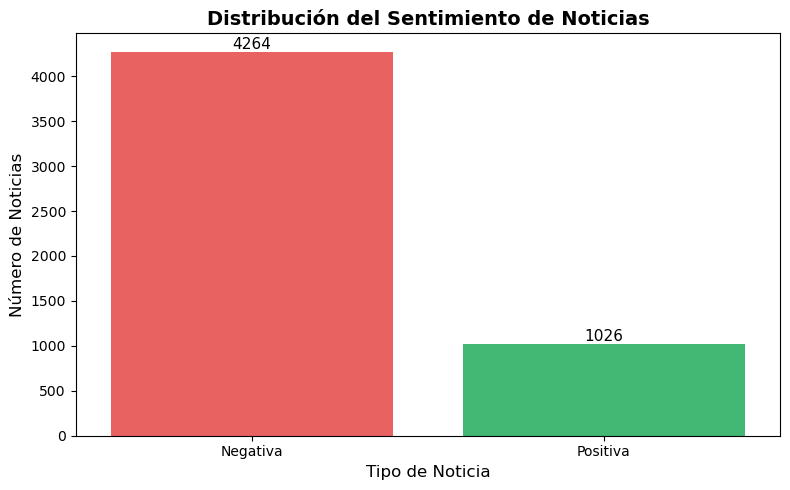

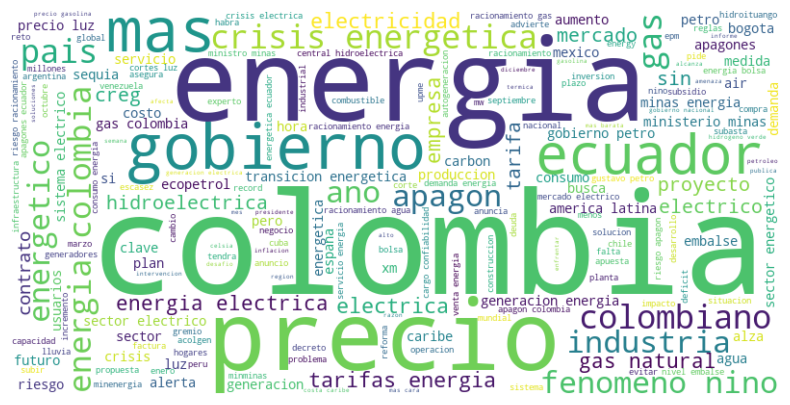

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud  # <-- La 'W' y 'C' mayúsculas son la clase, no el módulo

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Tipo_noticia',
    palette={'Negativa': '#ff4b4b', 'Positiva': '#2ecc71'}
)

# Títulos
plt.title('Distribución del Sentimiento de Noticias',
          fontsize=14, fontweight='bold')

# Etiquetas
plt.xlabel('Tipo de Noticia', fontsize=12)
plt.ylabel('Número de Noticias', fontsize=12)

# Agregar valores encima de cada barra
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

# 2. WordCloud (Si aquí fue el error)
textos_negativos = " ".join(df[df['Tipo_noticia'] == 'Negativa']['Titulo_norm'])

# CORRECTO: WordCloud() es la clase dentro del módulo wordcloud
wc = WordCloud(width=800, height=400, background_color='white').generate(textos_negativos)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_12024\2185698417.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sent_time = df.groupby(['Fecha','Tipo_noticia']).size().unstack(fill_value=0)


<Axes: xlabel='Fecha'>

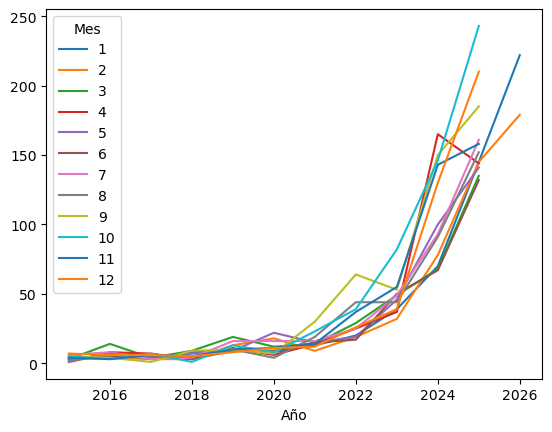

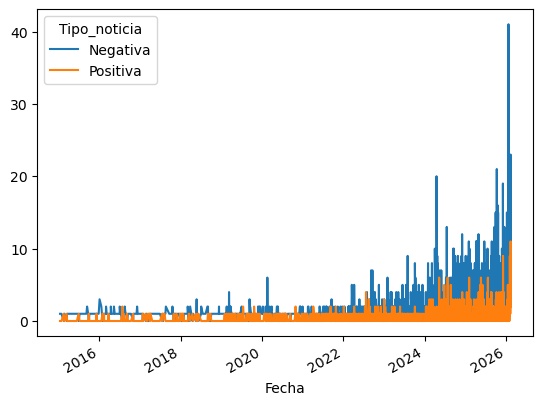

In [13]:
df.groupby(['Año','Mes']).size().unstack().plot()
sent_time = df.groupby(['Fecha','Tipo_noticia']).size().unstack(fill_value=0)
sent_time.plot()

C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_12024\3845296985.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['YearMonth','Tipo_noticia'])


<Figure size 640x480 with 0 Axes>

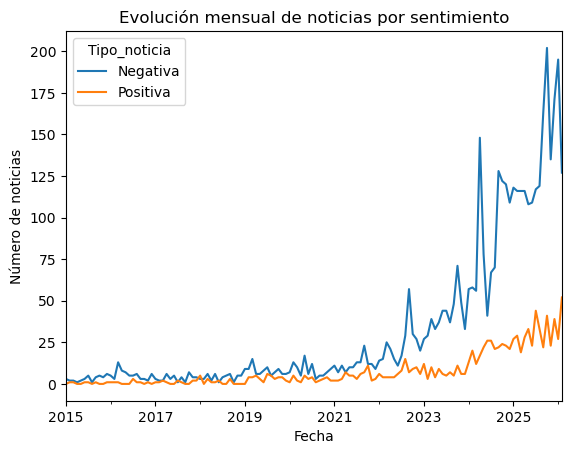

In [14]:
#Agrupación por mes
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.sort_values('Fecha')

df['YearMonth'] = df['Fecha'].dt.to_period('M')

# Conteo Mensual por noticias
sent_month = (
    df.groupby(['YearMonth','Tipo_noticia'])
      .size()
      .unstack(fill_value=0)
)

sent_month.index = sent_month.index.to_timestamp()
#Gráfico
plt.figure()
sent_month.plot()
plt.title('Evolución mensual de noticias por sentimiento')
plt.xlabel('Fecha')
plt.ylabel('Número de noticias')
plt.show()


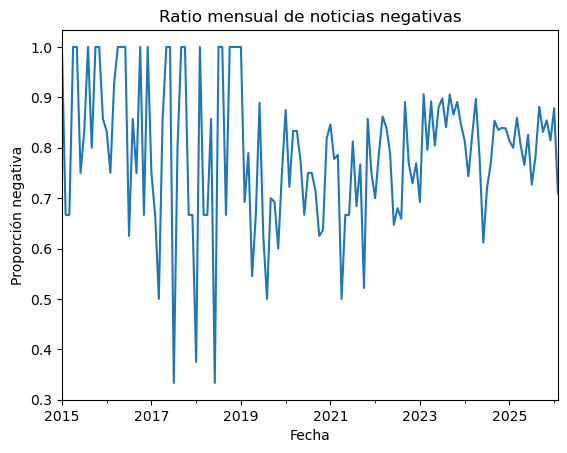

In [15]:
#Proporción mensual de negatividad
sent_month['Ratio_Neg'] = (
    sent_month['Negativa'] /
    (sent_month['Negativa'] + sent_month['Positiva'])
)
plt.figure()
sent_month['Ratio_Neg'].plot()
plt.title('Ratio mensual de noticias negativas')
plt.xlabel('Fecha')
plt.ylabel('Proporción negativa')
plt.show()



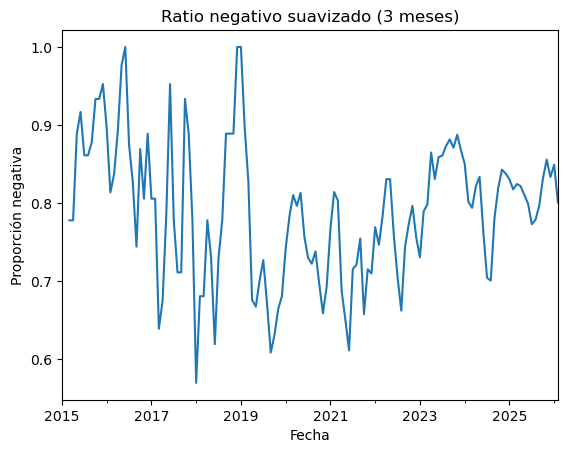

In [16]:
sent_month['Diferencial'] = (
    sent_month['Negativa'] - sent_month['Positiva']
)
sent_month['Ratio_Neg_3M'] = sent_month['Ratio_Neg'].rolling(3).mean()

plt.figure()
sent_month['Ratio_Neg_3M'].plot()
plt.title('Ratio negativo suavizado (3 meses)')
plt.xlabel('Fecha')
plt.ylabel('Proporción negativa')
plt.show()


In [17]:
df['Fuente'].value_counts()
df['Fuente'].value_counts(normalize=True)
noticias_por_fuente = df['Fuente'].value_counts()
noticias_por_fuente


Fuente
Infobae                     636
Energía Estratégica         303
LaRepublica.co              295
ELTIEMPO.COM                279
Portafolio.co               251
                           ... 
Foco Económico                1
Finanzas Digital              1
playersoflife.com             1
nationalgeographicla.com      0
Teletrece                     0
Name: count, Length: 587, dtype: int64

## Análisis por fuentes ##

In [18]:
tabla_fuente = pd.crosstab(
    df['Fuente'],
    df['Tipo_noticia'],
    normalize='index'
)

tabla_fuente


Tipo_noticia,Negativa,Positiva
Fuente,,
- CIPER Chile,0.666667,0.333333
20Minutos,1.000000,0.000000
360 Radio,0.833333,0.166667
724 | noticias,1.000000,0.000000
:.Periodicovirtual.com.:,0.000000,1.000000
...,...,...
www.gub.uy,1.000000,0.000000
www.laprensa.hn,1.000000,0.000000
www.metrolibre.com,1.000000,0.000000


In [19]:
noticias_por_fuente = df['Fuente'].value_counts()

tabla_frecuencia = (
    noticias_por_fuente
    .value_counts()
    .rename_axis('Numero_Noticias')
    .reset_index(name='Cantidad_Fuentes')
    .sort_values('Numero_Noticias')
)
tabla_frecuencia


,Numero_Noticias,Cantidad_Fuentes
20,0,2
0,1,285
1,2,91
2,3,56
4,4,23
3,5,26
5,6,15
10,7,5
7,8,8
9,9,6


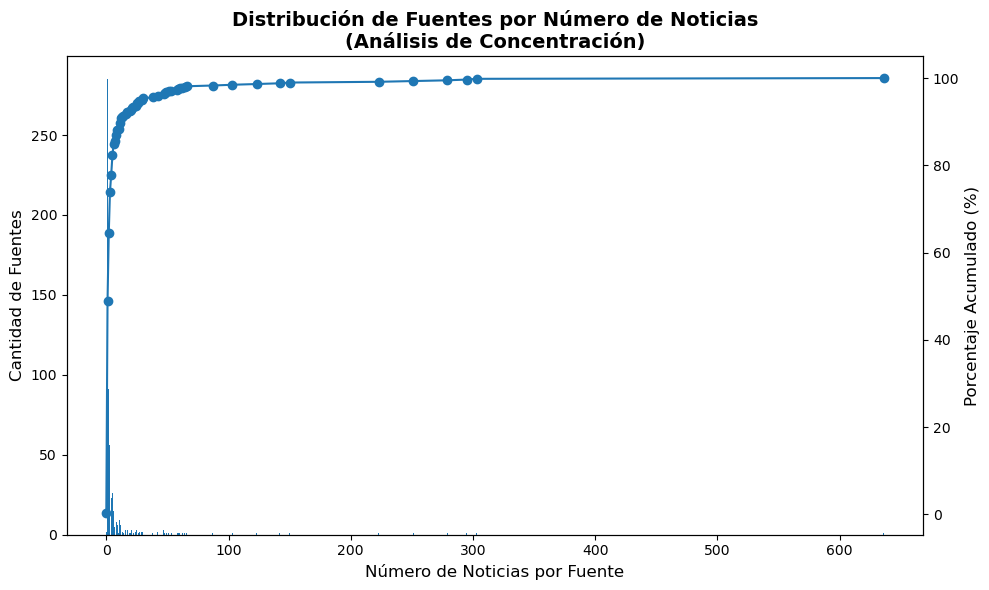

In [20]:
noticias_por_fuente = df['Fuente'].value_counts()

tabla_frecuencia = (
    noticias_por_fuente
    .value_counts()
    .rename_axis('Numero_Noticias')
    .reset_index(name='Cantidad_Fuentes')
    .sort_values('Numero_Noticias')
)

# Calcular acumulado
tabla_frecuencia['Acumulado'] = (
    tabla_frecuencia['Cantidad_Fuentes'].cumsum()
)

tabla_frecuencia['Acumulado_%'] = (
    tabla_frecuencia['Acumulado'] /
    tabla_frecuencia['Cantidad_Fuentes'].sum()
) * 100
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras
ax1.bar(
    tabla_frecuencia['Numero_Noticias'],
    tabla_frecuencia['Cantidad_Fuentes']
)

ax1.set_xlabel('Número de Noticias por Fuente', fontsize=12)
ax1.set_ylabel('Cantidad de Fuentes', fontsize=12)

# Segundo eje para acumulado
ax2 = ax1.twinx()
ax2.plot(
    tabla_frecuencia['Numero_Noticias'],
    tabla_frecuencia['Acumulado_%'],
    marker='o'
)

ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)

plt.title('Distribución de Fuentes por Número de Noticias\n(Análisis de Concentración)',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# MODELOS Y MINERÍA DE DATOS #

# PASO 1 #

Variable Objetivo

In [21]:
df['y'] = df['Tipo_noticia'].map({'Negativa': 1, 'Positiva': 0})


Train/Test Estratificado

In [22]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Titulo_norm'],
    df['y'],
    test_size=0.2,
    random_state=42,
    stratify=df['y']
)


Vectorización TF-IDF

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=3
)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

# PASO 2 #

In [24]:
# Métricas
from sklearn.metrics import classification_report, roc_auc_score


# ------------------ MODELOS LINEALES ------------------ #

# MODELO 1 - Naive Bayes (Multinomial)

In [25]:
from sklearn.naive_bayes import MultinomialNB

# Esto se puede podificar el alpha
model_nb = MultinomialNB()

model_nb.fit(X_train, y_train)

pred_nb = model_nb.predict(X_test)
proba_nb = model_nb.predict_proba(X_test)[:,1]

print("NAIVE BAYES")
print(classification_report(y_test, pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, proba_nb))

NAIVE BAYES
              precision    recall  f1-score   support

           0       0.98      0.68      0.80       205
           1       0.93      1.00      0.96       853

    accuracy                           0.94      1058
   macro avg       0.95      0.84      0.88      1058
weighted avg       0.94      0.94      0.93      1058

ROC-AUC: 0.9666428387613302


# MODELO 2 - Regresión Logística (Balanceada)

In [26]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)
proba_lr = model_lr.predict_proba(X_test)[:,1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, proba_lr))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       205
           1       0.98      0.98      0.98       853

    accuracy                           0.97      1058
   macro avg       0.95      0.94      0.95      1058
weighted avg       0.97      0.97      0.97      1058

ROC-AUC: 0.9873673977068024


In [27]:
feature_names = vectorizer.get_feature_names_out()
coefs = model_lr.coef_[0]

top_neg = sorted(zip(coefs, feature_names))[:20]
top_pos = sorted(zip(coefs, feature_names))[-20:]
top_neg

[(np.float64(-9.264695542178986), 'renovables'),
 (np.float64(-9.197915533626434), 'solar'),
 (np.float64(-7.315116576064157), 'renovable'),
 (np.float64(-5.9407048773101385), 'nina'),
 (np.float64(-5.805270768265028), 'solares'),
 (np.float64(-5.236929992897936), 'fenomeno nina'),
 (np.float64(-5.163093991856954), 'bajar'),
 (np.float64(-4.829849362013363), 'lluvias'),
 (np.float64(-4.446657804657764), 'eolica'),
 (np.float64(-3.4899124199437055), 'oferta'),
 (np.float64(-3.2326176209095783), 'baja'),
 (np.float64(-3.1953914539347896), 'energias renovables'),
 (np.float64(-3.1825687148143174), 'energia solar'),
 (np.float64(-2.898736050107454), 'energia eolica'),
 (np.float64(-2.8888017970426265), 'energia renovable'),
 (np.float64(-2.5751622535535366), 'energias'),
 (np.float64(-2.3372432313910645), 'fenomeno'),
 (np.float64(-2.283236329601496), 'bajar tarifas'),
 (np.float64(-2.01959078515093), 'barato'),
 (np.float64(-1.89389912968887), 'embalses')]

# MODELO 3 - Linear SVM (Balanceado)

In [28]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC no da probabilidades → lo calibramos
svm = LinearSVC(class_weight='balanced')

model_svm = CalibratedClassifierCV(svm)

model_svm.fit(X_train, y_train)

pred_svm = model_svm.predict(X_test)
proba_svm = model_svm.predict_proba(X_test)[:,1]

print("LINEAR SVM")
print(classification_report(y_test, pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, proba_svm))


LINEAR SVM
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       205
           1       0.98      0.99      0.98       853

    accuracy                           0.97      1058
   macro avg       0.96      0.95      0.95      1058
weighted avg       0.97      0.97      0.97      1058

ROC-AUC: 0.9902667772281475


# Comparación modelos lineales

In [29]:
results = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Logistic Regression', 'Linear SVM'],
    'ROC_AUC': [
        roc_auc_score(y_test, proba_nb),
        roc_auc_score(y_test, proba_lr),
        roc_auc_score(y_test, proba_svm)
    ]
})

print(results)

                Modelo   ROC_AUC
0          Naive Bayes  0.966643
1  Logistic Regression  0.987367
2           Linear SVM  0.990267


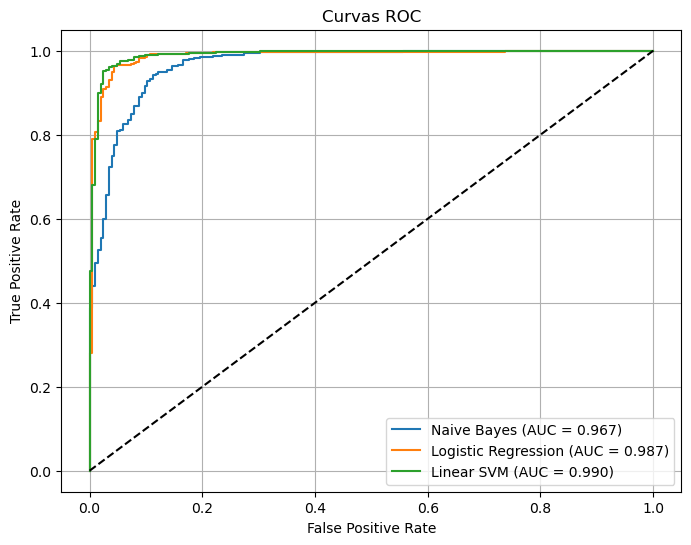

In [30]:
from sklearn.metrics import roc_curve, auc

# Probabilidades
fpr_nb, tpr_nb, _ = roc_curve(y_test, proba_nb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, proba_svm)

roc_auc_nb = auc(fpr_nb, tpr_nb)
roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8,6))

plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'Linear SVM (AUC = {roc_auc_svm:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
plt.legend()
plt.grid()
plt.show()


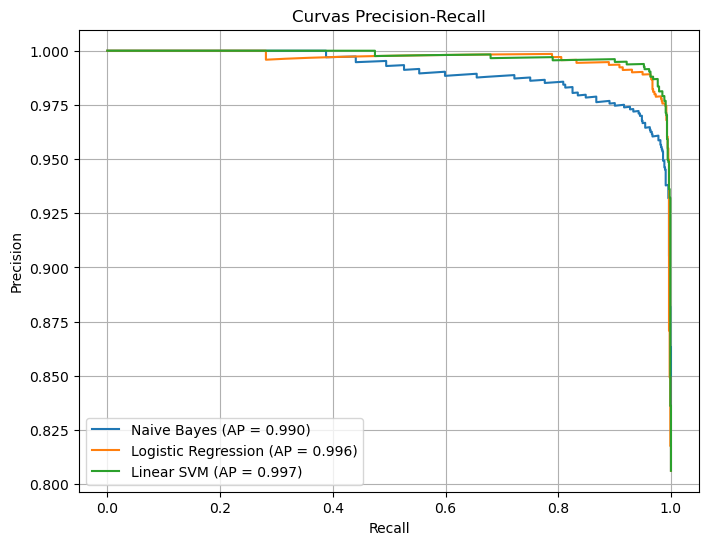

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_nb, recall_nb, _ = precision_recall_curve(y_test, proba_nb)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, proba_lr)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, proba_svm)

ap_nb = average_precision_score(y_test, proba_nb)
ap_lr = average_precision_score(y_test, proba_lr)
ap_svm = average_precision_score(y_test, proba_svm)

plt.figure(figsize=(8,6))

plt.plot(recall_nb, precision_nb, label=f'Naive Bayes (AP = {ap_nb:.3f})')
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {ap_lr:.3f})')
plt.plot(recall_svm, precision_svm, label=f'Linear SVM (AP = {ap_svm:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall')
plt.legend()
plt.grid()
plt.show()


# ------------------ MODELOS DE ENSAMBLE ------------------ #

# Modelo 1 Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)
proba_rf = model_rf.predict_proba(X_test)[:,1]

print("RANDOM FOREST")
print(classification_report(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, proba_rf))


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       205
           1       0.97      0.99      0.98       853

    accuracy                           0.97      1058
   macro avg       0.97      0.94      0.96      1058
weighted avg       0.97      0.97      0.97      1058

ROC-AUC: 0.9902353243931032


# Modelo 2 GRADIENT BOOSTING

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train.toarray(), y_train)

pred_gb = model_gb.predict(X_test.toarray())
proba_gb = model_gb.predict_proba(X_test.toarray())[:,1]

print("GRADIENT BOOSTING")
print(classification_report(y_test, pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, proba_gb))


GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       205
           1       0.98      0.99      0.99       853

    accuracy                           0.98      1058
   macro avg       0.98      0.96      0.97      1058
weighted avg       0.98      0.98      0.98      1058

ROC-AUC: 0.9890915849369514


# Modelo 3 XGBOOST

In [34]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)
proba_xgb = model_xgb.predict_proba(X_test)[:,1]

print("XGBOOST")
print(classification_report(y_test, pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, proba_xgb))


XGBOOST
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       205
           1       0.98      0.99      0.99       853

    accuracy                           0.98      1058
   macro avg       0.98      0.95      0.96      1058
weighted avg       0.98      0.98      0.98      1058

ROC-AUC: 0.9893946758928316


# ------------------ RED NEURONAL ------------------ #

In [35]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation='relu',
    max_iter=20,
    early_stopping=True,
    random_state=42
)

model_mlp.fit(X_train, y_train)

pred_mlp = model_mlp.predict(X_test)
proba_mlp = model_mlp.predict_proba(X_test)[:,1]

print("MLP")
print(classification_report(y_test, pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, proba_mlp))


MLP
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       205
           1       0.95      0.98      0.97       853

    accuracy                           0.94      1058
   macro avg       0.93      0.88      0.90      1058
weighted avg       0.94      0.94      0.94      1058

ROC-AUC: 0.9740714265290368


# Comparación modelos de ensamble

In [36]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_test, pred, proba, model):
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1_clase_0": f1_score(y_test, pred, pos_label=0),
        "F1_clase_1": f1_score(y_test, pred, pos_label=1),
        "F1_macro": f1_score(y_test, pred, average='macro'),
        "F1_weighted": f1_score(y_test, pred, average='weighted'),
        "ROC_AUC": roc_auc_score(y_test, proba),
        "Modelo_SK": model
    }
results_level2 = []

results_level2.append(evaluate_model("Random Forest", y_test, pred_rf, proba_rf, model_rf))
results_level2.append(evaluate_model("Gradient Boosting", y_test, pred_gb, proba_gb, model_gb))
results_level2.append(evaluate_model("XGBoost", y_test, pred_xgb, proba_xgb, model_xgb))
results_level2.append(evaluate_model("MLP", y_test, pred_mlp, proba_mlp, model_mlp))
results_level2.append(evaluate_model("Naive Bayes", y_test, pred_nb, proba_nb, model_nb))
results_level2.append(evaluate_model("Logistic Regression", y_test, pred_lr, proba_lr, model_lr))
results_level2.append(evaluate_model("Linear SVM", y_test, pred_svm, proba_svm, model_svm))

import pandas as pd
results_level2_df = pd.DataFrame(results_level2)

results_level2_df

,Modelo,Accuracy,F1_clase_0,F1_clase_1,F1_macro,F1_weighted,ROC_AUC,Modelo_SK
0,Random Forest,0.974480,0.931298,0.984330,0.957814,0.974054,0.990235,"(DecisionTreeClassifier(max_features='sqrt', r..."
1,Gradient Boosting,0.981096,0.950000,0.988345,0.969172,0.980915,0.989092,([DecisionTreeRegressor(criterion='friedman_ms...
2,XGBoost,0.977316,0.939394,0.986047,0.962720,0.977007,0.989395,"XGBClassifier(base_score=None, booster=None, c..."
3,MLP,0.943289,0.842105,0.965438,0.903772,0.941541,0.974071,"MLPClassifier(early_stopping=True, hidden_laye..."
4,Naive Bayes,0.935728,0.804598,0.961538,0.883068,0.931129,0.966643,MultinomialNB()
5,Logistic Regression,0.967864,0.915842,0.980140,0.947991,0.967682,0.987367,"LogisticRegression(class_weight='balanced', ma..."
6,Linear SVM,0.971645,0.925743,0.982477,0.954110,0.971484,0.990267,CalibratedClassifierCV(estimator=LinearSVC(cla...


In [37]:
# Escoger el mejor modelo según el F1_WEIGHTED
best_model = results_level2_df.sort_values('F1_weighted', ascending=False).iloc[0]
best_model_name = best_model['Modelo']
best_model_score = best_model['F1_weighted']
best_model_sk = best_model['Modelo_SK']
print("Mejor modelo según F1_weighted:")
print(best_model)

Mejor modelo según F1_weighted:
Modelo                                         Gradient Boosting
Accuracy                                                0.981096
F1_clase_0                                                  0.95
F1_clase_1                                              0.988345
F1_macro                                                0.969172
F1_weighted                                             0.980915
ROC_AUC                                                 0.989092
Modelo_SK      ([DecisionTreeRegressor(criterion='friedman_ms...
Name: 1, dtype: object


### **Entrenamiento del mejor modelo**

In [38]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Importar Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import os
from pathlib import Path

In [39]:
print(f"🏆 EL MODELO GANADOR ES: {best_model_name} (F1-Weighted Score: {best_model_score:.4f})")

🏆 EL MODELO GANADOR ES: Gradient Boosting (F1-Weighted Score: 0.9809)


In [40]:
# Carga datos
X, y = vectorizer.fit_transform(df['Titulo_norm']), df['y']

# Calculamos el ratio de desbalanceo para XGBoost (0=noticias positivas / 1=noticias negativas)
ratio_desbalanceo = float(np.sum(y == 1)) / np.sum(y == 0)

# Hiperparametrización del mejor modelo
grillas_parametros = {
    'Random Forest': {
        'n_estimators': [100, 200, 300], 
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],     # NUEVO
        'max_features': ['sqrt', 'log2']     # NUEVO
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300], 
        'learning_rate': [0.01, 0.05, 0.1],  # MEJORADO
        'max_depth': [3, 5, 7],              # NUEVO (Crítico)
        'subsample': [0.8, 1.0]              # NUEVO
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300], 
        'learning_rate': [0.01, 0.05, 0.1],  # MEJORADO
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],             # NUEVO
        'colsample_bytree': [0.8, 1.0]       # NUEVO
    },
    'MLP': {
        'hidden_layer_sizes': [(50,), (100,), (50, 50)], # MEJORADO (Añadida red profunda)
        'alpha': [0.0001, 0.001, 0.01],      # MEJORADO
        'activation': ['relu', 'tanh']       # NUEVO
    },
    'Naive Bayes': {
        'var_smoothing': np.logspace(0, -9, num=20)      # MEJORADO (Más granularidad)
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100]  # MEJORADO (Límites más amplios)
    },
    'Linear SVM': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100]  # MEJORADO (Límites más amplios)
    }
}

print(f"--- INICIANDO GRID SEARCH PARA {best_model_name} ---")

modelo_ganador = best_model_sk
grilla_ganador = grillas_parametros[best_model_name]

# Aseguramos usar 'f1_weighted' en el GridSearchCV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=modelo_ganador,
    param_grid=grilla_ganador,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print("\n--- RESULTADOS FINALES ---")
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"Mejor Score F1 Weighted K-Fold: {grid_search.best_score_:.4f}")

modelo_final = grid_search.best_estimator_

print("\nClassification Report del Mejor Modelo:")
y_pred = modelo_final.predict(X)
print(classification_report(y, y_pred))

--- INICIANDO GRID SEARCH PARA Gradient Boosting ---
Fitting 10 folds for each of 54 candidates, totalling 540 fits

--- RESULTADOS FINALES ---
Mejores Hiperparámetros: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Mejor Score F1 Weighted K-Fold: 0.9775

Classification Report del Mejor Modelo:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1026
           1       0.99      1.00      1.00      4264

    accuracy                           0.99      5290
   macro avg       1.00      0.98      0.99      5290
weighted avg       0.99      0.99      0.99      5290



In [41]:
X_full = vectorizer.fit_transform(df['Titulo_norm'])
y_full = df['y']
modelo_final.fit(X_full, y_full)

# Path para guardar modelos

# Guardar el vectorizador para uso futuro
joblib.dump(vectorizer, os.path.join(Path.cwd().parent, "src/models/vectorizer.joblib"))

# Guardar el modelo entrenado
joblib.dump(modelo_final, os.path.join(Path.cwd().parent, "src/models/news_model.joblib"))

['c:\\Users\\Jhon Fernando Tascón\\OneDrive - uniminuto.edu\\Documentos\\GitHub\\bot_futuros\\src/models/news_model.joblib']

In [42]:
# Agregar probabilidades al DataFrame original
df['Tipo_noticia'] = modelo_final.predict_proba(X_full)[:,1]
cols_keep = [
    "Titulo", "Fuente", "Fecha", "Hora", "url", "Titulo_norm", "Tipo_noticia"
]
df_final = df[cols_keep]
df_final.to_csv(os.path.join(Path.cwd().parent, "data/2_silver/datos_NOTICIAS.csv"), index=False)

# NUEVAS NOTICIAS #

In [55]:
#!pip install gnews pandas newspaper3k langdetect openpyxl
import pandas as pd
from gnews import GNews
from newspaper import Article
from langdetect import detect
from datetime import datetime
import time

In [56]:
#Configuración de la Conexión a Google News
google_news = GNews(
    language='es',
    country='CO',
    period='7d',          # Últimos 30 días
    max_results=100        # Ajustable
)
# Definición de Términos
queries = [ "niveles embalses SIN Colombia XM",
    "aportaciones hídricas sistema interconectado nacional Colombia",
    "índice ENFICC generación hidroeléctrica Colombia",
    "alerta racionamiento energía Colombia fenómeno del Niño",
    "déficit hídrico generación eléctrica Colombia",
    "probabilidad racionamiento eléctrico Colombia 2026",
    "reservas hídricas XM reporte semanal",
    "precio bolsa energía XM histórico Colombia",
    "precio spot energía Colombia variación diaria",
    "precio escasez CREG Colombia actualización",
    "componente restricciones precio energía Colombia",
    "cargo por confiabilidad impacto tarifa energía Colombia",
    "volatilidad precio energía mercado mayorista Colombia",
    "incremento precio energía usuarios no regulados Colombia",
    "resolución CREG mercado mayorista energía",
    "modificación cargo por confiabilidad CREG",
    "reforma mercado eléctrico colombiano",
    "subastas cargo por confiabilidad Colombia",
    "regulación contratos bilaterales energía Colombia",
    "medidas gobierno crisis energética Colombia",
    "intervención tarifaria sector eléctrico Colombia",
    "crecimiento demanda energía Colombia UPME",
    "proyección demanda eléctrica Colombia 2026",
    "consumo energía sector industrial Colombia",
    "demanda máxima SIN Colombia récord",
    "racionamiento industrial energía Colombia",
    "contratos bilaterales energía Colombia precios",
    "precio contratos largo plazo energía Colombia",
    "mercado derivados energía Colombia",
    "coberturas precio energía Colombia industriales",
    "estrategias compra energía usuarios no regulados",
    "riesgo precio energía contratos Colombia",
    "hidrología embalses generación hidroeléctrica Colombia",
    "precio de escasez confiabilidad sistema eléctrico Colombia"
    
]


In [59]:
import requests

url = data[0][2]["url"].split("?")[0]

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/121.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html"
}

resp = requests.get(url, headers=headers, allow_redirects=True, timeout=10)

print(resp)

<Response [200]>


In [60]:
from datetime import date
def generar_ventanas_mensuales(fecha_inicio, fecha_fin):
    ventanas = []
    actual = fecha_inicio

    while actual < fecha_fin:
        if actual.month == 12:
            siguiente = date(actual.year + 1, 1, 1)
        else:
            siguiente = date(actual.year, actual.month + 1, 1)

        ventanas.append((actual, siguiente))
        actual = siguiente

    return ventanas


fecha_inicio = date(2026,2,1)
fecha_fin = date.today()

ventanas = generar_ventanas_mensuales(fecha_inicio, fecha_fin)
len(ventanas)


2

In [61]:
data = []

for query in queries:
    print(f"\n🔎 Query: {query}")

    for inicio, fin in ventanas:
        print(f"  ⏳ {inicio} → {fin}")

        google_news.start_date = inicio
        google_news.end_date = fin

        try:
            noticias = google_news.get_news(query)
        except Exception as e:
            print("   ⚠️ Error:", e)
            continue

        for noticia in noticias:
            registro = {
                "Query": query,
                "Titulo": noticia.get("title"),
                "Fuente": noticia.get("publisher", {}).get("title"),
                "Fecha": noticia.get("published date"),
                "url": noticia.get("url")
            }
            data.append(registro)

        time.sleep(1)  # MUY IMPORTANTE para evitar bloqueos



🔎 Query: niveles embalses SIN Colombia XM
  ⏳ 2026-02-01 → 2026-03-01


C:\Users\Jhon Fernando Tascón\AppData\Local\Temp\ipykernel_12024\2475053798.py:13: UserWarning: 
Period (7d) will be ignored in favour of the start and end dates
  noticias = google_news.get_news(query)


  ⏳ 2026-03-01 → 2026-04-01


c:\Users\Public\miniconda3\envs\mipython\Lib\site-packages\gnews\gnews.py:128: UserWarning: The start and end dates should be at least 1 day apart.
  warnings.warn("The start and end dates should be at least 1 day apart.")



🔎 Query: aportaciones hídricas sistema interconectado nacional Colombia
  ⏳ 2026-02-01 → 2026-03-01
  ⏳ 2026-03-01 → 2026-04-01

🔎 Query: índice ENFICC generación hidroeléctrica Colombia
  ⏳ 2026-02-01 → 2026-03-01
  ⏳ 2026-03-01 → 2026-04-01

🔎 Query: alerta racionamiento energía Colombia fenómeno del Niño
  ⏳ 2026-02-01 → 2026-03-01
  ⏳ 2026-03-01 → 2026-04-01

🔎 Query: déficit hídrico generación eléctrica Colombia
  ⏳ 2026-02-01 → 2026-03-01
  ⏳ 2026-03-01 → 2026-04-01

🔎 Query: probabilidad racionamiento eléctrico Colombia 2026
  ⏳ 2026-02-01 → 2026-03-01
  ⏳ 2026-03-01 → 2026-04-01

🔎 Query: reservas hídricas XM reporte semanal
  ⏳ 2026-02-01 → 2026-03-01
  ⏳ 2026-03-01 → 2026-04-01

🔎 Query: precio bolsa energía XM histórico Colombia
  ⏳ 2026-02-01 → 2026-03-01
  ⏳ 2026-03-01 → 2026-04-01

🔎 Query: precio spot energía Colombia variación diaria
  ⏳ 2026-02-01 → 2026-03-01
  ⏳ 2026-03-01 → 2026-04-01

🔎 Query: precio escasez CREG Colombia actualización
  ⏳ 2026-02-01 → 2026-03-01


In [62]:
import pandas as pd
from pathlib import Path

# Convertir la lista de registros a DataFrame
df_noticias = pd.DataFrame(data)

# Ruta donde se guardará el archivo
ruta_salida = Path("noticias_scraping.csv")

# Guardar a CSV
df_noticias.to_csv(ruta_salida, index=False, encoding="utf-8")

print(f"Archivo generado correctamente en: {ruta_salida}")
print(f"Total de noticias guardadas: {len(df_noticias)}")

Archivo generado correctamente en: noticias_scraping.csv
Total de noticias guardadas: 530


In [1]:
import pandas as pd

df = pd.read_csv("noticias_scraping.csv")
indices_relevantes = [
0,1,2,3,6,7,8,9,10,11,12,14,15,16,18,22,23,24,25,26,27,28,29,31,32,33,36,38,39,40,
44,45,46,49,51,53,54,72,73,77,78,80,81,82,83,84,85,87,88,89,90,92,93,94,96,97,
216,218,220,222,223,228,238,
268,269,
308,
374,375,376,377,378,379,380,381,382,384,385,386,387,389,391,392,394,395,396,397,398,399,
402,
408,
427,
431,
437,
478,479,480,481,
482,483,484,485,487,488,489,490,
492,493,494,495,497,499
]
df= df.iloc[indices_relevantes]

print("Noticias originales:", len(df))
print("Noticias relevantes:", len(df))
df["Titulo"] = df["Titulo"].str.replace(r"\s*-\s*[^-]+$", "", regex=True)
df.head()

Noticias originales: 111
Noticias relevantes: 111


,Query,Titulo,Fuente,Fecha,url
0,niveles embalses SIN Colombia XM,Embalses al 77% y energía en bolsa por encima ...,Portafolio.co,"Tue, 10 Feb 2026 08:00:00 GMT",https://news.google.com/rss/articles/CBMivwFBV...
1,niveles embalses SIN Colombia XM,La pelea entre el Gobierno y las generadoras p...,LaRepublica.co,"Mon, 09 Feb 2026 08:00:00 GMT",https://news.google.com/rss/articles/CBMiwgFBV...
2,niveles embalses SIN Colombia XM,Precios de energía en bolsa caen cuatro veces ...,El Colombiano,"Sun, 22 Feb 2026 08:00:00 GMT",https://news.google.com/rss/articles/CBMirgFBV...
3,niveles embalses SIN Colombia XM,"Emergencia invernal no solo amenaza a Urrá, es...",Infobae,"Tue, 10 Feb 2026 08:00:00 GMT",https://news.google.com/rss/articles/CBMizgFBV...
6,niveles embalses SIN Colombia XM,Vertimientos de agua en Colombia: ¿cómo se rea...,Portafolio.co,"Mon, 16 Feb 2026 08:00:00 GMT",https://news.google.com/rss/articles/CBMilAFBV...


In [2]:
df["Titulo_norm"] = df["Titulo"].str.lower()

In [3]:
import joblib

modelo = joblib.load("news_model.joblib")
vectorizer = joblib.load("vectorizer.joblib")

c:\Users\Public\miniconda3\envs\mipython\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DummyClassifier from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Public\miniconda3\envs\mipython\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Public\miniconda3\envs\mipython\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GradientBoostingClassifier from

In [4]:
X_noticias = vectorizer.transform(df["Titulo_norm"])

In [5]:
df["probabilidad"] = modelo.predict_proba(X_noticias)[:,1]
df["prediccion"] = modelo.predict(X_noticias)
# Crear etiqueta interpretada
df["Etiqueta"] = df["prediccion"].map({0: "Positiva", 1: "Negativa"})

# Verificar resultados
df[["Titulo", "probabilidad", "prediccion", "Etiqueta"]].head()

,Titulo,probabilidad,prediccion,Etiqueta
0,Embalses al 77% y energía en bolsa por encima ...,0.950623,1,Negativa
1,La pelea entre el Gobierno y las generadoras p...,0.973594,1,Negativa
2,Precios de energía en bolsa caen cuatro veces ...,0.969254,1,Negativa
3,"Emergencia invernal no solo amenaza a Urrá, es...",0.950623,1,Negativa
6,Vertimientos de agua en Colombia: ¿cómo se rea...,0.950623,1,Negativa


In [7]:
df.to_excel("noticias_clasificadas.xlsx", index=False)

In [44]:
df_random_30 = df.sample(n=30)

df_random_30.to_csv("muestra_30_noticias.csv", index=False)

print("Archivo CSV generado: muestra_30_noticias.csv")

Archivo CSV generado: muestra_30_noticias.csv


In [45]:
pd.set_option('display.max_colwidth', None)
df_random_30[["Titulo", "Etiqueta"]]

,Titulo,Etiqueta
88,"Colombia superará los 4.000 MW en energías renovables en 2026, pero sigue pendiente una regulación clave para el sector",Positiva
382,Tarifas de energía en Colombia se estabilizarían en el primer semestre de 2026: Gobierno Petro explicó la razón,Negativa
380,Precio histórico de energía en Colombia: ¿por qué no baja la factura si la bolsa está en mínimos récord?,Positiva
495,Gustavo Petro volvió a cargar contra las hidroeléctricas por sobretasa: “Dejaron llenar los embalses y agudizaron la crisis”,Negativa
480,Precio de la energía en bolsa cae a mínimos históricos en 2026 en el país: Acolgen,Negativa
381,Colombia tendrá mecanismo para estabilizar tarifas en el primer trimestre: director de la CREG,Negativa
6,Vertimientos de agua en Colombia: ¿cómo se realiza esta acción desde los embalses?,Negativa
32,Urrá anuncia la reducción de precios en la energía luego de choque con el Presidente Petro,Negativa
3,"Emergencia invernal no solo amenaza a Urrá, estos son los embalses en Colombia que rozan su capacidad máxima",Negativa
84,"Sacudón en tarifas de energía en Colombia: ""nuevas reglas"" en precios para millones de usuarios",Negativa
